# 👟 Sneaker Brand Classification with CNN

This notebook builds a Convolutional Neural Network (CNN) to classify sneaker images by brand/type.

**Pipeline Overview:**
1. Data loading & preprocessing
2. Data augmentation
3. CNN model architecture
4. Training & validation
5. Evaluation & predictions
6. Sales data integration (optional)


## 1. Install & Import Dependencies

In [1]:
# Install required libraries (uncomment if needed)
# !pip install tensorflow keras matplotlib numpy pandas scikit-learn seaborn openpyxl

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

from sklearn.metrics import classification_report, confusion_matrix

print(f"TensorFlow version: {tf.__version__}")
print(f"GPU available: {len(tf.config.list_physical_devices('GPU')) > 0}")

# Reproducibility
np.random.seed(42)
tf.random.set_seed(42)

TensorFlow version: 2.20.0
GPU available: False


## 2. Configuration

In [2]:
# ── CONFIG ──────────────────────────────────────────────────────────────
IMG_HEIGHT   = 224          # Input image height
IMG_WIDTH    = 224          # Input image width
BATCH_SIZE   = 32
EPOCHS       = 30
LEARNING_RATE = 1e-3
DROPOUT_RATE  = 0.5

# Expected folder structure:
#   data/
#     train/
#       nike/      ← one subfolder per class
#       adidas/
#       puma/
#       ...
#     val/
#       nike/
#       adidas/
#       puma/
#       ...
#     test/        ← optional
#       ...

DATA_DIR   = Path("data")           # ← change to your dataset root
TRAIN_DIR  = DATA_DIR / "train"
VAL_DIR    = DATA_DIR / "val"
TEST_DIR   = DATA_DIR / "test"      # optional

MODEL_SAVE_PATH = "best_sneaker_cnn.h5"

# Sales data (from the uploaded xlsx)
SALES_FILE = "sneaker_sales_60000.xlsx"   # ← update path if needed
# ────────────────────────────────────────────────────────────────────────

print("Configuration set.")

Configuration set.


## 3. Explore Sales Data (Optional Context)

In [3]:
# Load the sneaker sales dataset to understand the brands/classes we need
try:
    df_sales = pd.read_excel(SALES_FILE)
    print("Sales data shape:", df_sales.shape)
    print("\nColumns:", df_sales.columns.tolist())
    display(df_sales.head())
except FileNotFoundError:
    print(f"Sales file '{SALES_FILE}' not found — skipping. Set SALES_FILE to your xlsx path.")
    df_sales = None

Sales file 'sneaker_sales_60000.xlsx' not found — skipping. Set SALES_FILE to your xlsx path.


In [4]:
# Plot top brands by sales volume (if sales data loaded)
if df_sales is not None:
    # Auto-detect the brand/category column
    brand_col = None
    for col in df_sales.columns:
        if col.lower() in ['brand', 'category', 'sneaker_brand', 'type', 'shoe_brand']:
            brand_col = col
            break

    if brand_col:
        top_brands = df_sales[brand_col].value_counts().head(10)
        fig, ax = plt.subplots(figsize=(10, 5))
        top_brands.plot(kind='bar', ax=ax, color='steelblue', edgecolor='black')
        ax.set_title('Top 10 Sneaker Brands by Sales Count', fontsize=14)
        ax.set_xlabel('Brand')
        ax.set_ylabel('Count')
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.show()
        print(f"\nDetected {df_sales[brand_col].nunique()} unique brands.")
    else:
        print("Could not auto-detect brand column. Please check df_sales.columns and set brand_col manually.")
        print(df_sales.describe())

## 4. Dataset Preparation

> **Note:** If you don't have images yet, see the cell below for a quick demo using synthetic data.

In [5]:
# ── QUICK DEMO: create synthetic dummy images if real data isn't ready ──
# Remove or skip this cell when you have real sneaker images.

DEMO_CLASSES = ['nike', 'adidas', 'puma', 'new_balance']
DEMO_SAMPLES = 50  # images per class per split

from PIL import Image
import random

def make_demo_dataset(root, classes, n_per_class):
    for split in ['train', 'val', 'test']:
        for cls in classes:
            folder = Path(root) / split / cls
            folder.mkdir(parents=True, exist_ok=True)
            for i in range(n_per_class):
                color = (random.randint(0,255), random.randint(0,255), random.randint(0,255))
                img = Image.new('RGB', (IMG_WIDTH, IMG_HEIGHT), color=color)
                img.save(folder / f"{cls}_{i:04d}.jpg")

if not TRAIN_DIR.exists():
    print("Creating synthetic demo dataset …")
    make_demo_dataset(DATA_DIR, DEMO_CLASSES, DEMO_SAMPLES)
    print("Done. Replace with real sneaker images for meaningful results.")
else:
    print("Real dataset found — skipping demo creation.")

Creating synthetic demo dataset …
Done. Replace with real sneaker images for meaningful results.


## 5. Data Generators with Augmentation

In [6]:
# Training augmentation — helps prevent overfitting
train_datagen = ImageDataGenerator(
    rescale=1.0 / 255,
    rotation_range=20,
    width_shift_range=0.15,
    height_shift_range=0.15,
    shear_range=0.1,
    zoom_range=0.2,
    horizontal_flip=True,
    brightness_range=[0.8, 1.2],
    fill_mode='nearest'
)

# Validation / test — only rescale, no augmentation
val_datagen = ImageDataGenerator(rescale=1.0 / 255)

train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True
)

val_generator = val_datagen.flow_from_directory(
    VAL_DIR,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

# Derived constants
NUM_CLASSES  = train_generator.num_classes
CLASS_NAMES  = list(train_generator.class_indices.keys())

print(f"Classes ({NUM_CLASSES}): {CLASS_NAMES}")
print(f"Training samples  : {train_generator.n}")
print(f"Validation samples: {val_generator.n}")

Found 200 images belonging to 4 classes.
Found 200 images belonging to 4 classes.
Classes (4): ['adidas', 'new_balance', 'nike', 'puma']
Training samples  : 200
Validation samples: 200


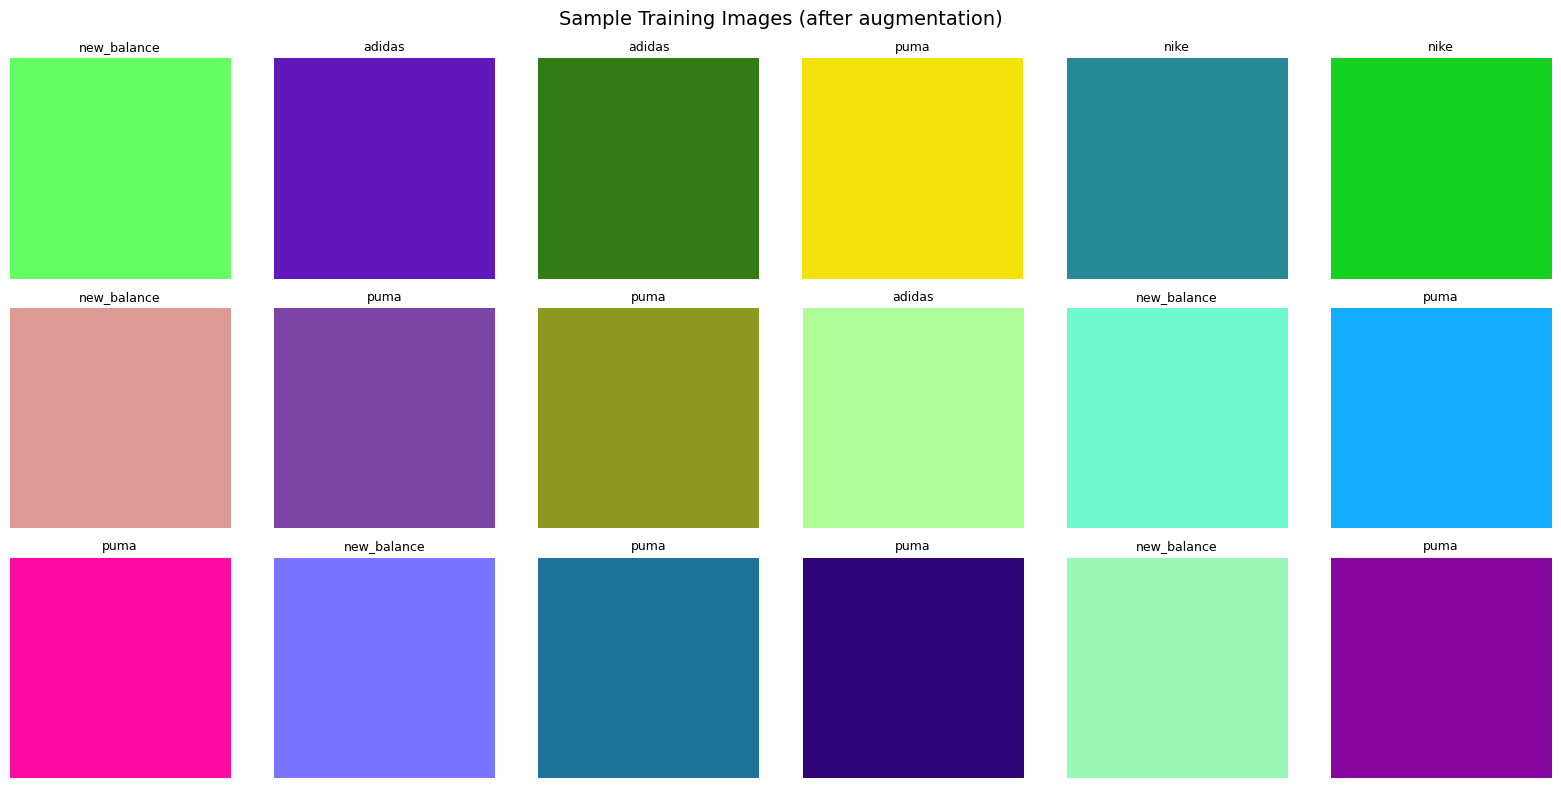

In [7]:
# Visualise a batch of augmented training images
images, labels = next(train_generator)
label_indices  = np.argmax(labels, axis=1)

fig, axes = plt.subplots(3, 6, figsize=(16, 8))
for i, ax in enumerate(axes.flat):
    if i < len(images):
        ax.imshow(images[i])
        ax.set_title(CLASS_NAMES[label_indices[i]], fontsize=9)
    ax.axis('off')
plt.suptitle('Sample Training Images (after augmentation)', fontsize=14)
plt.tight_layout()
plt.show()

## 6. CNN Architecture

Three options are provided — choose one:
- **Option A** — Custom CNN built from scratch (good for learning)
- **Option B** — Transfer learning with MobileNetV2 (recommended for small datasets)
- **Option C** — Transfer learning with EfficientNetB0 (highest accuracy)

In [8]:
# ── OPTION A: Custom CNN from scratch ───────────────────────────────────

def build_custom_cnn(input_shape, num_classes, dropout_rate=0.5):
    model = models.Sequential([
        # Block 1
        layers.Conv2D(32, (3, 3), activation='relu', padding='same',
                      input_shape=input_shape),
        layers.BatchNormalization(),
        layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),

        # Block 2
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),

        # Block 3
        layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),

        # Block 4
        layers.Conv2D(256, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),

        # Classifier head
        layers.GlobalAveragePooling2D(),
        layers.Dense(512, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(dropout_rate),
        layers.Dense(256, activation='relu'),
        layers.Dropout(dropout_rate / 2),
        layers.Dense(num_classes, activation='softmax')
    ], name="SneakerCNN_Custom")
    return model

model_A = build_custom_cnn(
    input_shape=(IMG_HEIGHT, IMG_WIDTH, 3),
    num_classes=NUM_CLASSES,
    dropout_rate=DROPOUT_RATE
)
model_A.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "SneakerCNN_Custom"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 224, 224, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 112, 112, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 56, 56, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 850,980 (3.25 MB)

 Trainable params: 848,548 (3.24 MB)

 Non-trainable params: 2,432 (9.50 KB)

In [9]:
# ── OPTION B: Transfer Learning — MobileNetV2 ───────────────────────────

def build_mobilenetv2(input_shape, num_classes, fine_tune_at=100):
    base = tf.keras.applications.MobileNetV2(
        input_shape=input_shape,
        include_top=False,
        weights='imagenet'
    )
    # Freeze all layers first
    base.trainable = False

    # Optionally unfreeze top layers for fine-tuning
    # for layer in base.layers[fine_tune_at:]:
    #     layer.trainable = True

    inputs = keras.Input(shape=input_shape)
    x = tf.keras.applications.mobilenet_v2.preprocess_input(inputs)
    x = base(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.4)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    return keras.Model(inputs, outputs, name="SneakerCNN_MobileNetV2")

model_B = build_mobilenetv2(
    input_shape=(IMG_HEIGHT, IMG_WIDTH, 3),
    num_classes=NUM_CLASSES
)
model_B.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "SneakerCNN_MobileNetV2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,586,948 (9.87 MB)

 Trainable params: 328,964 (1.25 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [10]:
# ── OPTION C: Transfer Learning — EfficientNetB0 ─────────────────────────

def build_efficientnet(input_shape, num_classes):
    base = tf.keras.applications.EfficientNetB0(
        input_shape=input_shape,
        include_top=False,
        weights='imagenet'
    )
    base.trainable = False

    inputs = keras.Input(shape=input_shape)
    x = base(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.4)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    return keras.Model(inputs, outputs, name="SneakerCNN_EfficientNetB0")

model_C = build_efficientnet(
    input_shape=(IMG_HEIGHT, IMG_WIDTH, 3),
    num_classes=NUM_CLASSES
)
model_C.summary()

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "SneakerCNN_EfficientNetB0"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,378,535 (16.70 MB)

 Trainable params: 328,964 (1.25 MB)

 Non-trainable params: 4,049,571 (15.45 MB)

## 7. Compile the Model

Select the model you want to train by changing `model = model_A/B/C`.

In [11]:
# ── SELECT MODEL ──────────────────────────────────────────────────────
model = model_B   # ← change to model_A or model_C as needed
# ──────────────────────────────────────────────────────────────────────

model.compile(
    optimizer=Adam(learning_rate=LEARNING_RATE),
    loss='categorical_crossentropy',
    metrics=['accuracy', tf.keras.metrics.TopKCategoricalAccuracy(k=3, name='top3_acc')]
)

print(f"Model '{model.name}' compiled.")
print(f"Trainable params: {model.count_params():,}")

Model 'SneakerCNN_MobileNetV2' compiled.
Trainable params: 2,586,948


## 8. Callbacks

In [12]:
callbacks = [
    # Stop early if val_loss stops improving
    EarlyStopping(
        monitor='val_accuracy',
        patience=7,
        restore_best_weights=True,
        verbose=1
    ),
    # Save only the best model
    ModelCheckpoint(
        MODEL_SAVE_PATH,
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    ),
    # Reduce LR when learning stagnates
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.3,
        patience=4,
        min_lr=1e-7,
        verbose=1
    )
]

print("Callbacks ready.")

Callbacks ready.


## 9. Train

In [14]:
history = model.fit(
    train_generator,
    epochs=10,
    validation_data=val_generator,
    callbacks=callbacks,
    verbose=1
)

print("\nTraining complete.")

Epoch 1/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.2185 - loss: 1.5591 - top3_acc: 0.7279
Epoch 1: val_accuracy did not improve from 0.25000
7/7 ━━━━━━━━━━━━━━━━━━━━ 19s 3s/step - accuracy: 0.2300 - loss: 1.5476 - top3_acc: 0.7250 - val_accuracy: 0.2500 - val_loss: 1.4588 - val_top3_acc: 0.7500 - learning_rate: 0.0010
Epoch 2/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 814ms/step - accuracy: 0.2239 - loss: 1.5970 - top3_acc: 0.7595
Epoch 2: val_accuracy did not improve from 0.25000
7/7 ━━━━━━━━━━━━━━━━━━━━ 11s 2s/step - accuracy: 0.2150 - loss: 1.5695 - top3_acc: 0.7350 - val_accuracy: 0.2500 - val_loss: 1.3890 - val_top3_acc: 0.7500 - learning_rate: 0.0010
Epoch 3/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 957ms/step - accuracy: 0.1664 - loss: 1.5456 - top3_acc: 0.6679
Epoch 3: val_accuracy did not improve from 0.25000
7/7 ━━━━━━━━━━━━━━━━━━━━ 11s 2s/step - accuracy: 0.2000 - loss: 1.4882 - top3_acc: 0.6950 - val_accuracy: 0.2500 - val_loss: 1.3888 - val_top3_acc: 0.7650 - learning_rate: 0.0010
Epoc

## 10. Training Curves

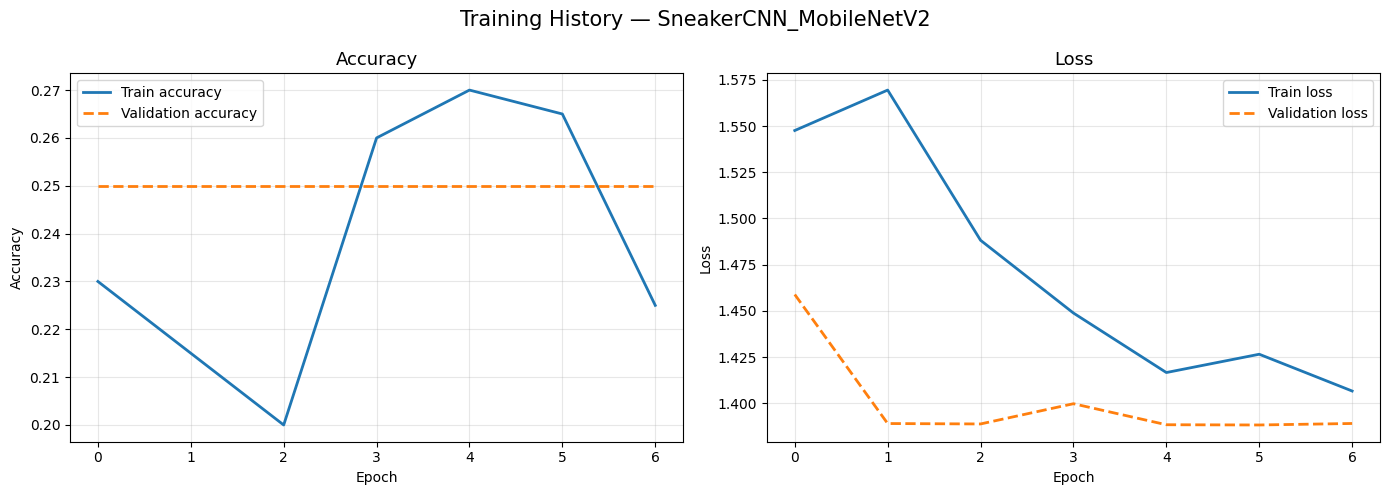

In [15]:
def plot_history(history):
    metrics = ['accuracy', 'loss']
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    for ax, metric in zip(axes, metrics):
        ax.plot(history.history[metric],         label=f'Train {metric}',      linewidth=2)
        ax.plot(history.history[f'val_{metric}'], label=f'Validation {metric}', linewidth=2, linestyle='--')
        ax.set_title(metric.capitalize(), fontsize=13)
        ax.set_xlabel('Epoch')
        ax.set_ylabel(metric.capitalize())
        ax.legend()
        ax.grid(alpha=0.3)

    plt.suptitle(f'Training History — {model.name}', fontsize=15)
    plt.tight_layout()
    plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
    plt.show()

plot_history(history)

## 11. Evaluation on Validation Set

In [16]:
val_generator.reset()
loss, acc, top3 = model.evaluate(val_generator, verbose=1)
print(f"\nValidation Accuracy : {acc:.4f}  ({acc*100:.2f}%)")
print(f"Validation Top-3 Acc: {top3:.4f}  ({top3*100:.2f}%)")
print(f"Validation Loss     : {loss:.4f}")

7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 647ms/step - accuracy: 0.2500 - loss: 1.4588 - top3_acc: 0.7500

Validation Accuracy : 0.2500  (25.00%)
Validation Top-3 Acc: 0.7500  (75.00%)
Validation Loss     : 1.4588


In [17]:
# Classification report & confusion matrix
val_generator.reset()
y_pred_probs = model.predict(val_generator, verbose=1)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = val_generator.classes

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

7/7 ━━━━━━━━━━━━━━━━━━━━ 6s 810ms/step

Classification Report:
              precision    recall  f1-score   support

      adidas       0.00      0.00      0.00        50
 new_balance       0.00      0.00      0.00        50
        nike       0.25      1.00      0.40        50
        puma       0.00      0.00      0.00        50

    accuracy                           0.25       200
   macro avg       0.06      0.25      0.10       200
weighted avg       0.06      0.25      0.10       200



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


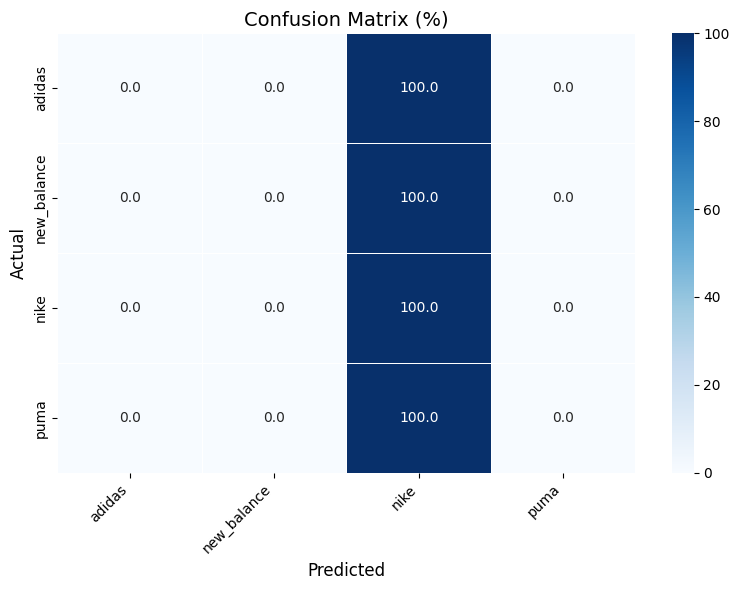

In [18]:
# Confusion matrix heatmap
cm = confusion_matrix(y_true, y_pred)
cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

fig, ax = plt.subplots(figsize=(max(8, NUM_CLASSES), max(6, NUM_CLASSES)))
sns.heatmap(
    cm_pct, annot=True, fmt='.1f', cmap='Blues',
    xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
    ax=ax, linewidths=0.5
)
ax.set_xlabel('Predicted', fontsize=12)
ax.set_ylabel('Actual',    fontsize=12)
ax.set_title('Confusion Matrix (%)', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

## 12. Predict on New Images

In [19]:
def predict_image(img_path, model, class_names, img_size=(224, 224)):
    """Load one image, run inference, return top-3 predictions."""
    img  = load_img(img_path, target_size=img_size)
    arr  = img_to_array(img) / 255.0
    arr  = np.expand_dims(arr, axis=0)

    probs   = model.predict(arr, verbose=0)[0]
    top3_idx = np.argsort(probs)[::-1][:3]

    results = [(class_names[i], float(probs[i])) for i in top3_idx]

    # Display
    plt.figure(figsize=(4, 4))
    plt.imshow(img)
    plt.axis('off')
    title = '\n'.join([f"{name}: {conf*100:.1f}%" for name, conf in results])
    plt.title(title, fontsize=10)
    plt.tight_layout()
    plt.show()

    return results


# ── EXAMPLE USAGE ──────────────────────────────────────────────────────
# predictions = predict_image("path/to/your/sneaker.jpg", model, CLASS_NAMES)
# print(predictions)

# Batch prediction on test set (if test folder exists)
if TEST_DIR.exists():
    test_datagen = ImageDataGenerator(rescale=1.0/255)
    test_gen = test_datagen.flow_from_directory(
        TEST_DIR, target_size=(IMG_HEIGHT, IMG_WIDTH),
        batch_size=BATCH_SIZE, class_mode='categorical', shuffle=False
    )
    test_loss, test_acc, test_top3 = model.evaluate(test_gen, verbose=1)
    print(f"Test Accuracy: {test_acc*100:.2f}%   Top-3: {test_top3*100:.2f}%")
else:
    print("No test/ folder found. Set TEST_DIR or call predict_image() directly.")

Found 200 images belonging to 4 classes.
7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 587ms/step - accuracy: 0.2500 - loss: 1.4588 - top3_acc: 0.7500
Test Accuracy: 25.00%   Top-3: 75.00%


## 13. Fine-Tuning (Optional)

Unfreeze the top layers of the base model and train at a lower learning rate for an accuracy boost.

In [20]:
# ── Only run for transfer-learning models (B or C) ─────────────────────
FINE_TUNE = False   # ← set True to enable

if FINE_TUNE and hasattr(model.layers[1], 'layers'):
    base_model = model.layers[1]          # second layer is the base
    FINE_TUNE_AT = len(base_model.layers) - 30   # unfreeze last 30 layers

    base_model.trainable = True
    for layer in base_model.layers[:FINE_TUNE_AT]:
        layer.trainable = False

    model.compile(
        optimizer=Adam(learning_rate=1e-5),   # much lower LR for fine-tuning
        loss='categorical_crossentropy',
        metrics=['accuracy', tf.keras.metrics.TopKCategoricalAccuracy(k=3, name='top3_acc')]
    )

    print(f"Fine-tuning from layer {FINE_TUNE_AT}/{len(base_model.layers)}.")
    history_ft = model.fit(
        train_generator,
        epochs=10,
        validation_data=val_generator,
        callbacks=callbacks,
        verbose=1
    )
    plot_history(history_ft)
else:
    print("Fine-tuning skipped (FINE_TUNE=False or custom CNN selected).")

Fine-tuning skipped (FINE_TUNE=False or custom CNN selected).


## 14. Save & Export

In [21]:
# Save final model
model.save("sneaker_cnn_final.h5")
print("Model saved to sneaker_cnn_final.h5")

# Save class names for inference
import json
with open("class_names.json", "w") as f:
    json.dump(CLASS_NAMES, f)
print("Class names saved to class_names.json")

# Export to TensorFlow Lite (for mobile/edge deployment)
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()
with open("sneaker_cnn.tflite", "wb") as f:
    f.write(tflite_model)
print("TFLite model saved to sneaker_cnn.tflite")

Model saved to sneaker_cnn_final.h5
Class names saved to class_names.json
Saved artifact at '/tmp/tmp0peqha04'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor_184')
Output Type:
  TensorSpec(shape=(None, 4), dtype=tf.float32, name=None)
Captures:
  135414725082576: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135412547545488: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135412547546832: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135412547546448: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135412547546640: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135412852320656: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135412547544144: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135412547542032: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135412547545296: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135412

## 15. Sales Data Integration

Combine model predictions with the sales dataset for richer analytics.

In [22]:
if df_sales is not None and brand_col:
    # Accuracy by brand — which brands are easiest to classify?
    results_df = pd.DataFrame({
        'true_label': [CLASS_NAMES[i] for i in y_true],
        'pred_label': [CLASS_NAMES[i] for i in y_pred]
    })
    results_df['correct'] = results_df['true_label'] == results_df['pred_label']

    per_class_acc = results_df.groupby('true_label')['correct'].mean().sort_values(ascending=False)

    fig, ax = plt.subplots(figsize=(10, 5))
    per_class_acc.plot(kind='bar', ax=ax, color='coral', edgecolor='black')
    ax.set_title('Per-Class Classification Accuracy', fontsize=14)
    ax.set_xlabel('Sneaker Brand')
    ax.set_ylabel('Accuracy')
    ax.axhline(acc, color='blue', linestyle='--', label=f'Overall ({acc:.2f})')
    ax.legend()
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
else:
    print("Sales data not loaded — skipping integration cell.")

Sales data not loaded — skipping integration cell.
